pipeline_run3_final.py
======================
Self-contained Run 3 dental caries surface classification pipeline.

Usage:
    python pipeline_run3_final.py

Steps:
1. Extract 13 geometric features from 500 cases
2. Train a Random Forest classifier (GroupShuffleSplit by case_id)
3. Re-classify all 500 cases with Smart Fallback
4. Evaluate predictions against XML ground truth
5. Plot feature importance chart
6. Generate README_run3.html documentation
"""

# Imports libraries and modules
Imports libraries and modules used throughout the RF model pipeline.

In [20]:
# =========================================================
# Imports libraries and modules used throughout the RF model pipeline.
# =========================================================
import os
import sys
import json
import math
import warnings
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import joblib
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib
# NOTE: matplotlib.use('Agg') removed — Jupyter uses inline backend.
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Constants and Configurations 

In [21]:
# =========================================================
# Constants and Configurations
# =========================================================

# Derived Features Calculation - Statistical Aggregation & Geometric Interpretation
# FEATURE_COLS for this cell's version (14 features including y_max).
FEATURE_COLS = [
    'is_upper',         # Binary: 1 for upper jaw, 0 for lower jaw
    'x_mean', 'y_mean', # Centroid: Average relative position of caries
    'x_std', 'y_std',   # Dispersion: Spread of the caries region
    'x_min', 'x_max',   # Boundary: Left/Right limits of caries
    'y_min', 'y_max',   # Boundary: Top/Bottom limits of caries
    'x_range',          # Width: x_max - x_min
    'y_range',          # Height: y_max - y_min
    'x_centroid_dist',  # Center Distance: abs(np.mean(x_rel) - 0.5), low values suggest Occlusal
    'aspect_ratio',     # Tooth Shape: w / h ratio
    'coverage',         # Density: Caries area / Tooth area ratio
]

"""Ordered list of the 13 geometric features used by the RF model."""

VALID_SURFACES = ["Occlusal", "Mesial", "Distal", "Other"]
"""The four surface classes used in evaluation."""

MAX_TILT_DEG = 45.0
"""Clamp extreme PCA rotation angles above this threshold."""

MIN_CLUSTER_SIZE = 15
"""Minimum connected-component size for noise removal."""

LEFT_BOUND = 0.40
"""X-thirds left boundary (0.00 - 0.40 = left zone)."""

RIGHT_BOUND = 0.60
"""X-thirds right boundary (0.60 - 1.00 = right zone)."""


'X-thirds right boundary (0.60 - 1.00 = right zone).'

# Path configuration
adjust these paths as needed for your environment.

In [22]:
# =========================================================
# Path configuration --- adjust these paths as needed for your environment.
# =========================================================
try:
    _THIS_DIR = Path(__file__).resolve().parent
except NameError:
    # Running inside Jupyter / interactive — use the notebook's working directory.
    _THIS_DIR = Path.cwd()

_SP_DIR = _THIS_DIR.parent.parent
SEG_DIR = _SP_DIR / "week2-Tooth Detection & Segmentation" / "500-segmentation+recognition"
CARIES_DIR = _SP_DIR / "week3-Caries-to-Tooth Mapping" / "dental_analysis_output"
GT_ROOT = _SP_DIR / "data" / "500 cases with annotation"
OUTPUT_ROOT = _THIS_DIR / "PCA_Output_Run3"
MODEL_PATH = _THIS_DIR / "rf_classify_ml.pkl"

# Global model placeholder.
rf_model = None

# Progress bar function
for long-running loops.

In [23]:
# =========================================================
# Progress bar helper function for long-running loops.
# =========================================================
def _progress_bar(current, total, prefix="Progress", bar_length=30):
    """
    Print an inline text-based progress bar that overwrites itself.

    Args:
        current (int): Current step number (1-indexed).
        total (int): Total number of steps.
        prefix (str): Label displayed before the bar.
        bar_length (int): Character width of the bar.
    """
    fraction = current / max(total, 1)
    filled = int(bar_length * fraction)
    bar = chr(9608) * filled + chr(9617) * (bar_length - filled)
    print(
        f"\r   {prefix} [{bar}] {fraction*100:.0f}% ({current}/{total})",
        end="", flush=True,
    )
    if current >= total:
        print()



# XML Ground-Truth Parser
extracts tooth and surface info from AIM XML files.

In [24]:
# =========================================================
# XML Ground-Truth Parser --- extracts tooth and surface info from AIM XML files.
# =========================================================
AIM_NS = "gme://caCORE.caCORE/4.4/edu.northwestern.radiology.AIM"
ISO_NS = "uri:iso.org:21090"
NS = {"aim": AIM_NS, "iso": ISO_NS}

SNODENT_SURFACE_MAP = {
    "144414D": "Occlusal", "146014D": "Distal", "145374D": "Mesial",
    "144474D": "Occlusal", "146074D": "Distal", "145434D": "Mesial",
}

DISPLAY_NAME_TO_SURFACE = {
    "Occlusal surface": "Occlusal", "Occlusal Surface": "Occlusal",
    "Distal Surface": "Distal", "Distal surface": "Distal",
    "Mesial Surface": "Mesial", "Mesial surface": "Mesial",
}

SNODENT_TO_FDI = {
    "161006D": "11", "160842D": "12", "160288D": "13", "161286D": "14",
    "160450D": "15", "160770D": "16", "161204D": "17", "160618D": "18",
    "160194D": "21", "160132D": "22", "160506D": "23", "161340D": "24",
    "160682D": "25", "161074D": "26", "160386D": "27", "160922D": "28",
    "161136D": "31", "160556D": "32", "160068D": "33", "160326D": "34",
    "161248D": "35", "160730D": "36", "161166D": "37", "160580D": "38",
    "160964D": "41", "160350D": "42", "160894D": "43", "160230D": "44",
    "161412D": "45", "160770D": "46", "161102D": "47", "160488D": "48",
}


def _get_display_name(element):
    """Extract the displayName value from an ISO-namespaced XML element."""
    dn = element.find("iso:displayName", NS)
    return dn.get("value", "") if dn is not None else ""


def snodent_display_to_fdi(display_name):
    """
    Convert a SNODENT display name to an FDI two-digit tooth identifier.

    Args:
        display_name (str): SNODENT descriptive name.

    Returns:
        str: FDI identifier (e.g. '16'), or empty string if unparseable.
    """
    dn = display_name.lower()
    if "upper" in dn and "right" in dn:
        quadrant = 1
    elif "upper" in dn and "left" in dn:
        quadrant = 2
    elif "lower" in dn and "left" in dn:
        quadrant = 3
    elif "lower" in dn and "right" in dn:
        quadrant = 4
    else:
        return ""

    tooth_map = {
        "central incisor": 1, "lateral incisor": 2, "canine": 3,
        "first premolar": 4, "second premolar": 5, "first molar": 6,
        "second molar": 7, "third molar": 8,
    }
    for name, pos in tooth_map.items():
        if name in dn:
            return f"{quadrant}{pos}"
    return ""


def parse_aim_xml(xml_path):
    """
    Parse a single AIM XML annotation file to extract tooth and surface.

    Args:
        xml_path (str): Path to the AIM XML file.

    Returns:
        dict or None: {'tooth': str, 'surface': str}, or None on failure.
    """
    try:
        tree = ET.parse(xml_path)
    except Exception:
        return None

    root = tree.getroot()
    anns = root.find("aim:imageAnnotations", NS)
    if anns is None:
        return None
    ann = anns.find("aim:ImageAnnotation", NS)
    if ann is None:
        return None

    tooth = ""
    surface = ""
    phys_coll = ann.find("aim:imagingPhysicalEntityCollection", NS)
    if phys_coll is not None:
        entity = phys_coll.find("aim:ImagingPhysicalEntity", NS)
        if entity is not None:
            char_coll = entity.find(
                "aim:imagingPhysicalEntityCharacteristicCollection", NS
            )
            if char_coll is not None:
                for ch in char_coll.findall(
                    "aim:ImagingPhysicalEntityCharacteristic", NS
                ):
                    q_idx_el = ch.find("aim:questionIndex", NS)
                    q_idx = q_idx_el.get("value", "") if q_idx_el is not None else ""
                    tc = ch.find("aim:typeCode", NS)
                    if tc is None:
                        continue
                    code = tc.get("code", "")
                    display = _get_display_name(tc)
                    if q_idx == "0":
                        tooth = snodent_display_to_fdi(display)
                        if not tooth:
                            tooth = SNODENT_TO_FDI.get(code, "")
                    elif q_idx == "1":
                        surface = SNODENT_SURFACE_MAP.get(code, "")
                        if not surface:
                            surface = DISPLAY_NAME_TO_SURFACE.get(display, "")

    return {"tooth": tooth, "surface": surface}


def parse_case_ground_truth(case_folder):
    """
    Parse all AIM XML ground-truth files in a case folder.

    Args:
        case_folder (Path): Directory containing *.xml annotation files.

    Returns:
        list[dict]: Each dict has 'tooth' (str FDI) and 'surface' (str).
    """
    ground_truth_list = []
    for xml_file in sorted(Path(case_folder).glob("*.xml")):
        parsed = parse_aim_xml(str(xml_file))
        if parsed is None:
            continue
        tooth = str(parsed.get("tooth", "Unknown"))
        surface = parsed.get("surface", "Other")
        if surface not in VALID_SURFACES:
            surface = "Other"
        ground_truth_list.append({"tooth": tooth, "surface": surface})
    return ground_truth_list


# PCA & Geometry functions
functions for tooth orientation, bounding boxes, and noise removal.

In [25]:
# =========================================================
# PCA & Geometry Helpers --- functions for tooth orientation, bounding boxes, and noise removal.
# =========================================================

def is_upper_jaw(tooth_id):
    """Check whether a tooth belongs to the upper jaw (quadrant 1 or 2)."""
    return int(str(tooth_id)[0]) in [1, 2]


def get_quadrant(tooth_id):
    """Extract the FDI quadrant (1-4) from a tooth identifier."""
    return int(str(tooth_id)[0])


def get_bbox(pts):
    """Compute the axis-aligned bounding box: (x_min, y_min, width, height)."""
    p = np.array(pts, dtype=np.float64)
    bbox_min, bbox_max = np.min(p, 0), np.max(p, 0)
    return bbox_min[0], bbox_min[1], bbox_max[0] - bbox_min[0], bbox_max[1] - bbox_min[1]


def rotate(pts, center, angle):
    """Rotate 2D points around a centre by a given angle (radians)."""
    p = np.array(pts, dtype=np.float64) - center
    c, s = np.cos(angle), np.sin(angle)
    return np.dot(p, np.array([[c, -s], [s, c]]).T) + center


def remove_small_clusters(caries_pts, min_cluster=MIN_CLUSTER_SIZE):
    """
    Remove noise from caries points by discarding small connected components.

    Args:
        caries_pts (list or np.ndarray): Nx2 caries pixel coordinates.
        min_cluster (int): Minimum cluster size to keep.

    Returns:
        np.ndarray: Filtered caries points.
    """
    if len(caries_pts) < min_cluster:
        return caries_pts
    pts = np.array(caries_pts, dtype=np.int32)
    x_min, y_min = pts.min(axis=0)
    x_max, y_max = pts.max(axis=0)
    pad = 2
    w = x_max - x_min + 1 + 2 * pad
    h = y_max - y_min + 1 + 2 * pad
    mask = np.zeros((h, w), dtype=np.uint8)
    shifted = pts - np.array([x_min - pad, y_min - pad])
    mask[shifted[:, 1], shifted[:, 0]] = 255
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    keep = np.zeros_like(mask)
    for lbl in range(1, n_labels):
        if stats[lbl, cv2.CC_STAT_AREA] >= min_cluster:
            keep[labels == lbl] = 255
    ys, xs = np.where(keep > 0)
    if len(xs) == 0:
        return caries_pts
    return np.column_stack([xs + x_min - pad, ys + y_min - pad]).astype(np.float64)


def perform_pca(points, tooth_id):
    """
    PCA-based 4-rule tooth orientation alignment.

    Args:
        points (list or np.ndarray): Nx2 tooth pixel coordinates.
        tooth_id (str or int): FDI tooth identifier.

    Returns:
        tuple: (mean_center, rotation_angle_rad, was_clamped).
    """
    pts = np.array(points, dtype=np.float64).reshape(-1, 2)
    mean = np.mean(pts, axis=0)
    centered = pts - mean

    _, eigvecs = cv2.PCACompute(centered.astype(np.float32), mean=None)
    primary_eigenvector = eigvecs[0].astype(np.float64)
    secondary_eigenvector = eigvecs[1].astype(np.float64)

    # Rule 1: vertical axis has larger |Y| component.
    if abs(primary_eigenvector[1]) >= abs(secondary_eigenvector[1]):
        vertical_axis = primary_eigenvector.copy()
        horizontal_axis = secondary_eigenvector.copy()
    else:
        vertical_axis = secondary_eigenvector.copy()
        horizontal_axis = primary_eigenvector.copy()

    # Rule 2: vertical direction based on jaw.
    upper = is_upper_jaw(tooth_id)
    if upper:
        if vertical_axis[1] < 0:
            vertical_axis = -vertical_axis
    else:
        if vertical_axis[1] > 0:
            vertical_axis = -vertical_axis

    # Rule 3: horizontal direction based on quadrant.
    quadrant = get_quadrant(tooth_id)
    if quadrant in [1, 4]:
        if horizontal_axis[0] < 0:
            horizontal_axis = -horizontal_axis
    else:
        if horizontal_axis[0] > 0:
            horizontal_axis = -horizontal_axis

    angle_from_x = math.atan2(vertical_axis[1], vertical_axis[0])
    target_angle = math.pi / 2 if upper else -math.pi / 2
    rotation_angle = target_angle - angle_from_x

    while rotation_angle > math.pi:
        rotation_angle -= 2 * math.pi
    while rotation_angle < -math.pi:
        rotation_angle += 2 * math.pi

    # Rule 4: clamp extreme rotations.
    clamped = False
    if abs(math.degrees(rotation_angle)) > MAX_TILT_DEG:
        rotation_angle = 0.0
        clamped = True

    return mean, rotation_angle, clamped


def build_seg_map(seg_data):
    """Build tooth_id -> pixel_coordinates mapping from segmentation JSON."""
    return {
        str(t["tooth_id"]): t.get("pixel_coordinates", [])
        for t in seg_data.get("teeth_data", [])
    }



# File I/O functions
functions to load segmentation and caries mapping JSON files.

In [26]:
# =========================================================
# File I/O Helpers --- functions to load segmentation and caries mapping JSON files.
# =========================================================

def _load_json_file(path):
    """Load JSON file, return None if missing."""
    if not path.exists():
        return None
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def _load_seg_case(case_id):
    """Load segmentation JSON for a single case."""
    return _load_json_file(SEG_DIR / f"case {case_id}" / f"case_{case_id}_results.json")


def _load_caries_case(case_id):
    """Load caries mapping JSON for a single case."""
    return _load_json_file(CARIES_DIR / f"case {case_id}" / f"case_{case_id}_caries_mapping.json")


# Feature Extraction function
main function to extract geometric features for a tooth-caries pair.

In [27]:
# =========================================================
# Feature Extraction --- main function to extract geometric features for a tooth-caries pair.
# =========================================================

def _extract_ml_feature_dict(tooth_id, tooth_pts, caries_pts):
    """
    Extract 13 geometric features for one caries-tooth pair.

    Args:
        tooth_id (str): FDI tooth identifier.
        tooth_pts (list): Tooth mask pixel coordinates.
        caries_pts (list): Caries region pixel coordinates.

    Returns:
        dict or None: Feature dictionary keyed by FEATURE_COLS names.
    """
    caries_clean = remove_small_clusters(caries_pts)
    if len(caries_clean) == 0:
        return None

    center, angle, _ = perform_pca(tooth_pts, tooth_id)
    tooth_rot = rotate(tooth_pts, center, angle)
    caries_rot = rotate(caries_clean, center, angle)

    bbox_x, bbox_y, w, h = get_bbox(tooth_rot)
    if w <= 0 or h <= 0:
        return None

    x_rel = np.clip((caries_rot[:, 0] - bbox_x) / w, 0.0, 1.0)
    y_rel = np.clip((caries_rot[:, 1] - bbox_y) / h, 0.0, 1.0)

    return {
        "is_upper": 1 if int(str(tooth_id)[0]) in [1, 2] else 0,
        "x_mean": float(np.mean(x_rel)),
        "y_mean": float(np.mean(y_rel)),
        "x_std": float(np.std(x_rel)),
        "y_std": float(np.std(y_rel)),
        "x_min": float(np.min(x_rel)),
        "x_max": float(np.max(x_rel)),
        "y_min": float(np.min(y_rel)),
        "y_max": float(np.max(y_rel)),
        "x_range": float(np.max(x_rel) - np.min(x_rel)),
        "y_range": float(np.max(y_rel) - np.min(y_rel)),
        "x_centroid_dist": float(abs(np.mean(x_rel) - 0.5)),
        "aspect_ratio": float(w / h),
        "coverage": float(len(caries_clean) / (len(tooth_pts) + 1e-6)),
    }


# Visualize how geometric features

[SAVED] feature_engineering_visualization.png (dpi=300)


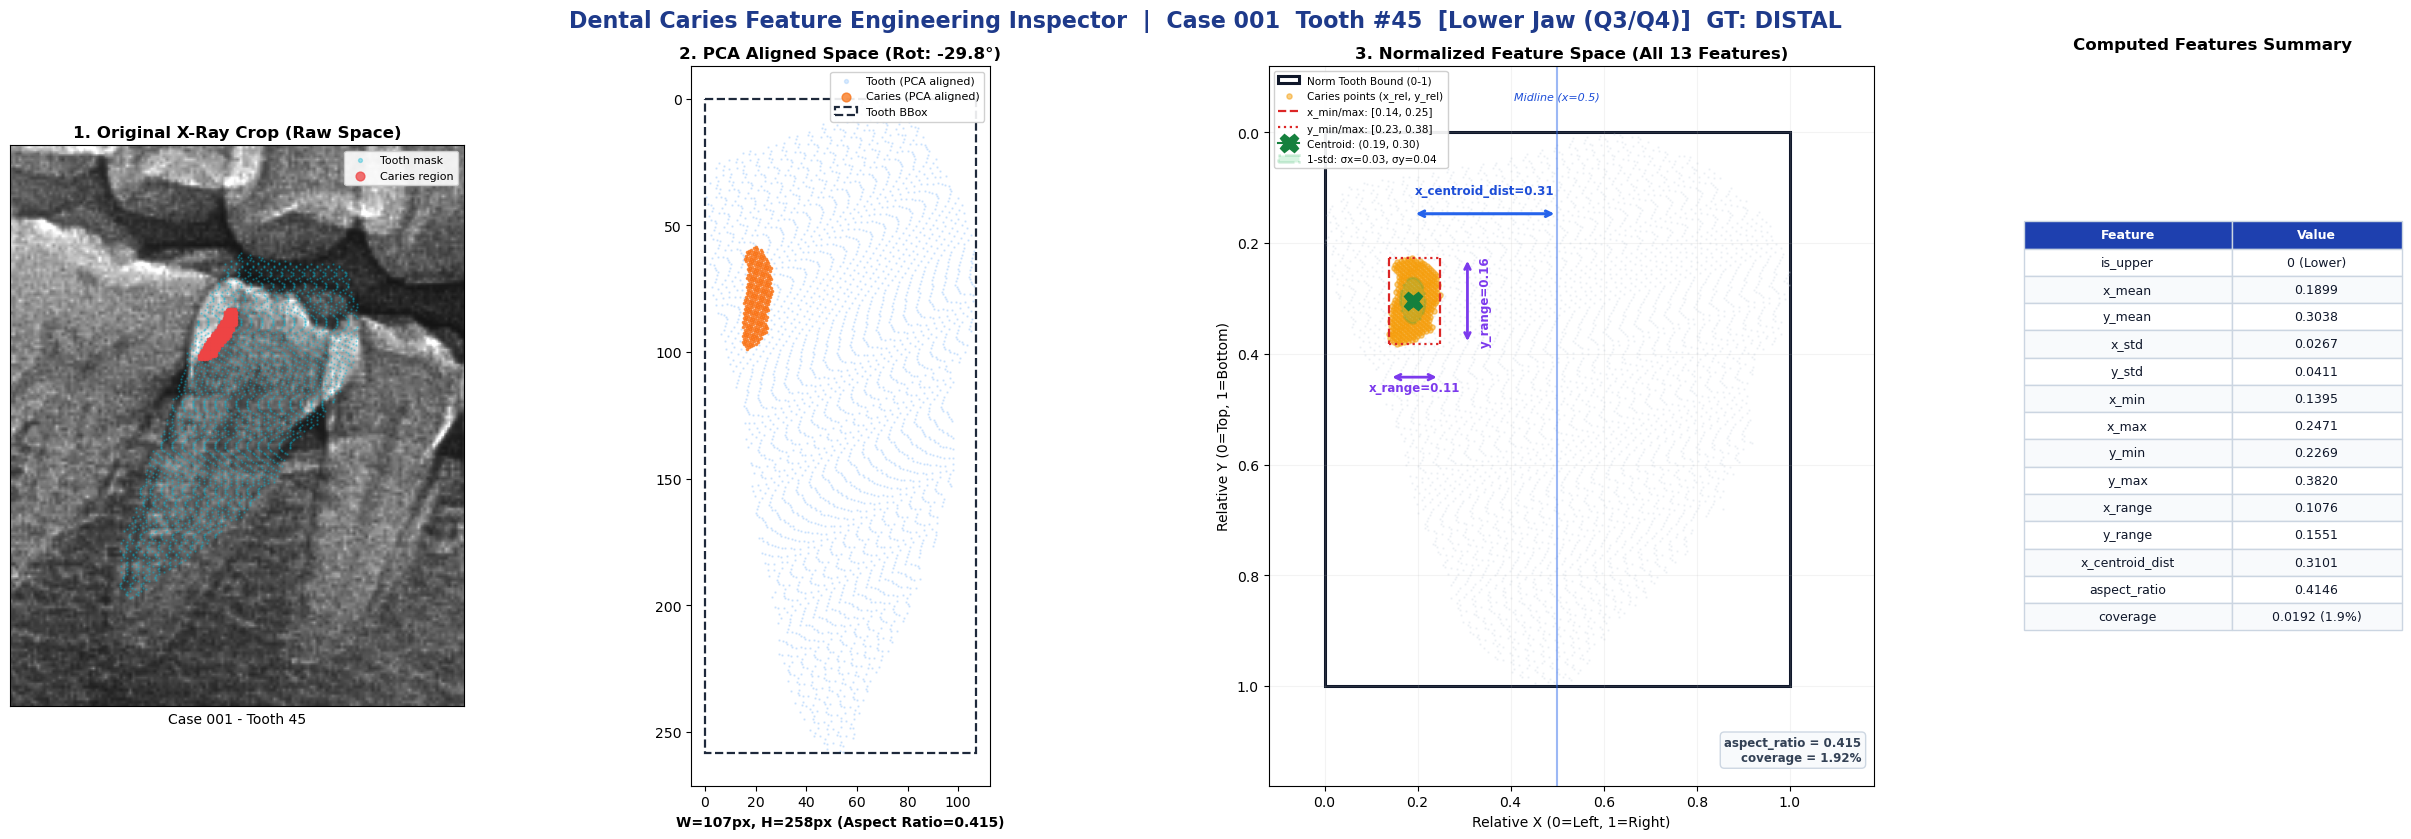

In [28]:
from matplotlib.patches import Ellipse, Rectangle

def visualize_feature_engineering_demo(demo_case_id=1, demo_tooth_idx=0, save_output=True):
    """
    Visualize all 13 engineered geometric features on real segmentation data.
    Publication-quality 4-panel figure:
      1. Original cropped X-ray with tooth & caries segmentation overlay
      2. PCA-aligned tooth & caries in pixel space with bounding box
      3. Normalized coordinate space (0-1) explicitly rendering all 13 features
      4. Computed feature summary table
    """
    seg_data = _load_seg_case(demo_case_id)
    caries_data = _load_caries_case(demo_case_id)
    if seg_data is None or caries_data is None:
        print(f'[SKIP] Case {demo_case_id}: missing segmentation or caries data.'); return

    caries_teeth = [
        t for t in caries_data.get('teeth_caries_data', [])
        if t.get('has_caries') and len(t.get('caries_coordinates', [])) > 0
    ]
    if not caries_teeth:
        print(f'[SKIP] Case {demo_case_id}: no teeth with caries data.'); return

    demo_tooth_idx = min(demo_tooth_idx, len(caries_teeth) - 1)
    tooth_info = caries_teeth[demo_tooth_idx]
    tooth_id = str(tooth_info['tooth_id'])
    caries_pts_raw = np.array(tooth_info['caries_coordinates'], dtype=np.float64)

    seg_map = build_seg_map(seg_data)
    tooth_pts_raw = np.array(seg_map.get(tooth_id, []), dtype=np.float64)
    if len(tooth_pts_raw) < 10:
        print(f'[SKIP] Tooth {tooth_id}: too few segmentation points.'); return

    gt_folder = GT_ROOT / f'case {demo_case_id}'
    gt_surface = 'N/A'
    if gt_folder.exists():
        gt_list = parse_case_ground_truth(gt_folder)
        gt_lookup = {str(g['tooth']): g['surface'] for g in gt_list}
        gt_surface = gt_lookup.get(tooth_id, 'N/A')

    # Extraction
    caries_clean = remove_small_clusters(caries_pts_raw)
    center, angle, clamped = perform_pca(tooth_pts_raw, tooth_id)
    tooth_rot = rotate(tooth_pts_raw, center, angle)
    caries_rot = rotate(caries_clean, center, angle)

    bbox_x, bbox_y, w, h = get_bbox(tooth_rot)
    if w <= 0 or h <= 0: return

    tx_rel = np.clip((tooth_rot[:, 0] - bbox_x) / w, 0.0, 1.0)
    ty_rel = np.clip((tooth_rot[:, 1] - bbox_y) / h, 0.0, 1.0)
    x_rel = np.clip((caries_rot[:, 0] - bbox_x) / w, 0.0, 1.0)
    y_rel = np.clip((caries_rot[:, 1] - bbox_y) / h, 0.0, 1.0)

    f = {
        'is_upper':        1 if int(tooth_id[0]) in [1, 2] else 0,
        'x_mean':          float(np.mean(x_rel)),
        'y_mean':          float(np.mean(y_rel)),
        'x_std':           float(np.std(x_rel)),
        'y_std':           float(np.std(y_rel)),
        'x_min':           float(np.min(x_rel)),
        'x_max':           float(np.max(x_rel)),
        'y_min':           float(np.min(y_rel)),
        'y_max':           float(np.max(y_rel)),
        'x_range':         float(np.max(x_rel) - np.min(x_rel)),
        'y_range':         float(np.max(y_rel) - np.min(y_rel)),
        'x_centroid_dist': float(abs(np.mean(x_rel) - 0.5)),
        'aspect_ratio':    float(w / h),
        'coverage':        float(len(caries_clean) / (len(tooth_pts_raw) + 1e-6)),
    }

    jaw_str = 'Upper Jaw (Q1/Q2)' if f['is_upper'] == 1 else 'Lower Jaw (Q3/Q4)'
    fig = plt.figure(figsize=(24, 8), constrained_layout=True)
    gs = fig.add_gridspec(1, 4, width_ratios=[2.4, 2.4, 3.2, 2.0], wspace=0.25)
    fig.suptitle(f'Dental Caries Feature Engineering Inspector  |  Case {demo_case_id:03d}  Tooth #{tooth_id}  [{jaw_str}]  GT: {gt_surface.upper()}',
                 fontsize=16, fontweight='bold', color='#1e3a8a', y=1.03)

    # Panel 1: Original X-Ray Crop
    ax1 = fig.add_subplot(gs[0])
    img_path = GT_ROOT / f'case {demo_case_id}' / f'case_{demo_case_id}.png'
    if img_path.exists():
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        all_pts = np.vstack([tooth_pts_raw, caries_pts_raw])
        pad = 70
        xmin_c = max(int(all_pts[:, 0].min()) - pad, 0)
        xmax_c = min(int(all_pts[:, 0].max()) + pad, img.shape[1])
        ymin_c = max(int(all_pts[:, 1].min()) - pad, 0)
        ymax_c = min(int(all_pts[:, 1].max()) + pad, img.shape[0])
        crop = img[ymin_c:ymax_c, xmin_c:xmax_c].copy()
        t_crop = tooth_pts_raw - np.array([xmin_c, ymin_c])
        c_crop = caries_pts_raw - np.array([xmin_c, ymin_c])
        ax1.imshow(crop)
        st = max(1, len(t_crop) // 2500)
        ax1.scatter(t_crop[::st, 0], t_crop[::st, 1], c='#06b6d4', s=0.5, alpha=0.35, label='Tooth mask')
        sc = max(1, len(c_crop) // 1200)
        ax1.scatter(c_crop[::sc, 0], c_crop[::sc, 1], c='#ef4444', s=2.5, alpha=0.75, label='Caries region')
        ax1.legend(loc='upper right', fontsize=8, markerscale=4, framealpha=0.9)
    else:
        ax1.text(0.5, 0.5, 'Image not found', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('1. Original X-Ray Crop (Raw Space)', fontsize=12, fontweight='bold')
    ax1.set_xlabel(f'Case {demo_case_id:03d} - Tooth {tooth_id}', fontsize=10)
    ax1.set_xticks([]); ax1.set_yticks([])

    # Panel 2: PCA-Aligned Space
    ax2 = fig.add_subplot(gs[1])
    t_rot = tooth_rot - np.array([bbox_x, bbox_y])
    c_rot = caries_rot - np.array([bbox_x, bbox_y])
    st_r = max(1, len(t_rot) // 3000)
    ax2.scatter(t_rot[::st_r, 0], t_rot[::st_r, 1], c='#93c5fd', s=0.5, alpha=0.35, label='Tooth (PCA aligned)')
    sc_r = max(1, len(c_rot) // 1500)
    ax2.scatter(c_rot[::sc_r, 0], c_rot[::sc_r, 1], c='#f97316', s=2.5, alpha=0.75, label='Caries (PCA aligned)')
    ax2.add_patch(Rectangle((0, 0), w, h, fill=False, color='#1e293b', lw=1.6, linestyle='--', label='Tooth BBox'))
    ax2.set_title(f'2. PCA Aligned Space (Rot: {float(np.degrees(angle)):.1f}°)', fontsize=12, fontweight='bold')
    ax2.set_xlabel(f'W={w:.0f}px, H={h:.0f}px (Aspect Ratio={f["aspect_ratio"]:.3f})', fontsize=10, fontweight='semibold')
    ax2.invert_yaxis(); ax2.set_aspect('equal')
    ax2.legend(loc='upper right', fontsize=8, markerscale=4, framealpha=0.9)

    # Panel 3: Normalized Feature Space
    ax3 = fig.add_subplot(gs[2])
    ax3.add_patch(Rectangle((0, 0), 1, 1, fill=False, color='#0f172a', lw=2.2, label='Norm Tooth Bound (0-1)'))
    st_norm = max(1, len(tx_rel) // 4000)
    ax3.scatter(tx_rel[::st_norm], ty_rel[::st_norm], c='#cbd5e1', s=0.5, alpha=0.25, zorder=1)
    ax3.scatter(x_rel, y_rel, alpha=0.5, c='#f59e0b', s=14, label='Caries points (x_rel, y_rel)', zorder=3)
    ax3.vlines([f['x_min'], f['x_max']], f['y_min'], f['y_max'], color='#dc2626', linestyle='--', lw=1.6,
               label=f"x_min/max: [{f['x_min']:.2f}, {f['x_max']:.2f}]", zorder=4)
    ax3.hlines([f['y_min'], f['y_max']], f['x_min'], f['x_max'], color='#dc2626', linestyle=':', lw=1.6,
               label=f"y_min/max: [{f['y_min']:.2f}, {f['y_max']:.2f}]", zorder=4)
    y_arr = min(f['y_max'] + 0.06, 1.04)
    ax3.annotate('', xy=(f['x_max'], y_arr), xytext=(f['x_min'], y_arr),
                 arrowprops=dict(arrowstyle='<->', color='#7c3aed', lw=2))
    ax3.text((f['x_min'] + f['x_max']) / 2, y_arr + 0.025, f"x_range={f['x_range']:.2f}", color='#7c3aed', fontweight='bold', ha='center', fontsize=8.5)
    x_arr = min(f['x_max'] + 0.06, 1.04)
    ax3.annotate('', xy=(x_arr, f['y_max']), xytext=(x_arr, f['y_min']),
                 arrowprops=dict(arrowstyle='<->', color='#7c3aed', lw=2))
    ax3.text(x_arr + 0.025, (f['y_min'] + f['y_max']) / 2, f"y_range={f['y_range']:.2f}", color='#7c3aed', fontweight='bold', va='center', fontsize=8.5, rotation=90)
    ax3.plot(f['x_mean'], f['y_mean'], marker='X', color='#15803d', markersize=13, zorder=6, label=f"Centroid: ({f['x_mean']:.2f}, {f['y_mean']:.2f})")
    ell = Ellipse((f['x_mean'], f['y_mean']), width=2 * f['x_std'], height=2 * f['y_std'],
                  fill=True, facecolor='#22c55e', alpha=0.18, edgecolor='#16a34a', linestyle='-.', lw=1.8,
                  label=f"1-std: σx={f['x_std']:.2f}, σy={f['y_std']:.2f}", zorder=5)
    ax3.add_patch(ell)
    ax3.axvline(0.5, color='#2563eb', alpha=0.45, linestyle='-', lw=1.5)
    y_cd = max(f['y_min'] - 0.08, 0.04)
    ax3.annotate('', xy=(f['x_mean'], y_cd), xytext=(0.5, y_cd), arrowprops=dict(arrowstyle='<->', color='#2563eb', lw=2.2))
    ax3.text((0.5 + f['x_mean']) / 2, y_cd - 0.035, f"x_centroid_dist={f['x_centroid_dist']:.2f}", color='#1d4ed8', fontweight='bold', ha='center', fontsize=8.5)
    ax3.text(0.5, -0.06, 'Midline (x=0.5)', color='#1d4ed8', ha='center', fontsize=8, fontstyle='italic')
    ax3.text(0.98, 0.03, f"aspect_ratio = {f['aspect_ratio']:.3f}\ncoverage = {f['coverage']*100:.2f}%",
             transform=ax3.transAxes, fontsize=8.5, fontweight='bold', color='#334155', ha='right', va='bottom',
             bbox=dict(boxstyle='round,pad=0.35', facecolor='#f8fafc', edgecolor='#cbd5e1', alpha=0.95))
    ax3.set_xlim(-0.12, 1.18); ax3.set_ylim(1.18, -0.12)
    ax3.set_title('3. Normalized Feature Space (All 13 Features)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Relative X (0=Left, 1=Right)', fontsize=10)
    ax3.set_ylabel('Relative Y (0=Top, 1=Bottom)', fontsize=10)
    ax3.grid(True, alpha=0.15)
    ax3.legend(loc='upper left', fontsize=7.5, framealpha=0.92)

    # Panel 4: Table
    ax4 = fig.add_subplot(gs[3]); ax4.axis('off')
    ax4.set_title('Computed Features Summary', fontsize=12, fontweight='bold', pad=12)
    table_rows = [
        ['is_upper', f"{f['is_upper']} ({'Upper' if f['is_upper'] else 'Lower'})"]
    ] + [[k, f"{f[k]:.4f} ({f[k]*100:.1f}%)" if k == 'coverage' else f"{f[k]:.4f}"] for k in list(f.keys())[1:]]
    table = ax4.table(cellText=table_rows, colLabels=['Feature', 'Value'], cellLoc='center', loc='center', colWidths=[0.55, 0.45])
    table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.0, 1.4)
    for (r_idx, c_idx), cell in table.get_celld().items():
        if r_idx == 0:
            cell.set_facecolor('#1e40af'); cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor('#f8fafc' if r_idx % 2 == 0 else 'white')
            cell.set_text_props(color='#0f172a')
        cell.set_edgecolor('#cbd5e1')
    if save_output:
        save_p = 'feature_engineering_visualization.png'
        fig.savefig(save_p, dpi=300, bbox_inches='tight', facecolor='white')
        print(f'[SAVED] {save_p} (dpi=300)')
    plt.show()

visualize_feature_engineering_demo(demo_case_id=1, demo_tooth_idx=0)


# Interactive Feature Visualization (Plotly)
Interactive Jupyter visualization for debugging the feature extraction pipeline.  
Supports zoom, pan, hover, and point selection.  
Uses the same real segmentation data loaded by `visualize_feature_engineering_demo` above.

In [29]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def visualize_feature_engineering_interactive(demo_case_id=1, demo_tooth_idx=0):
    """
    Interactive Plotly feature inspector for dental caries surface classification.
    Explicitly renders all 13 features with zoom, pan, hover, legend groups, and side table.
    """
    seg_data = _load_seg_case(demo_case_id)
    caries_data = _load_caries_case(demo_case_id)
    if seg_data is None or caries_data is None:
        print(f'[SKIP] Case {demo_case_id}: missing data.'); return

    caries_teeth = [
        t for t in caries_data.get('teeth_caries_data', [])
        if t.get('has_caries') and len(t.get('caries_coordinates', [])) > 0
    ]
    if not caries_teeth:
        print(f'[SKIP] Case {demo_case_id}: no caries teeth.'); return

    idx = min(demo_tooth_idx, len(caries_teeth) - 1)
    tooth_info = caries_teeth[idx]
    tooth_id = str(tooth_info['tooth_id'])
    caries_pts_raw = np.array(tooth_info['caries_coordinates'], dtype=np.float64)

    seg_map = build_seg_map(seg_data)
    tooth_pts_raw = np.array(seg_map.get(tooth_id, []), dtype=np.float64)
    if len(tooth_pts_raw) < 10:
        print(f'[SKIP] Tooth {tooth_id}: too few points.'); return

    gt_folder = GT_ROOT / f'case {demo_case_id}'
    gt_surface = 'N/A'
    if gt_folder.exists():
        gt_list = parse_case_ground_truth(gt_folder)
        gt_lookup = {str(g['tooth']): g['surface'] for g in gt_list}
        gt_surface = gt_lookup.get(tooth_id, 'N/A')

    caries_clean = remove_small_clusters(caries_pts_raw)
    center, angle, clamped = perform_pca(tooth_pts_raw, tooth_id)
    tooth_rot = rotate(tooth_pts_raw, center, angle)
    caries_rot = rotate(caries_clean, center, angle)

    bbox_x, bbox_y, w, h = get_bbox(tooth_rot)
    if w <= 0 or h <= 0: return

    tx_rel = np.clip((tooth_rot[:, 0] - bbox_x) / w, 0.0, 1.0)
    ty_rel = np.clip((tooth_rot[:, 1] - bbox_y) / h, 0.0, 1.0)
    x_rel = np.clip((caries_rot[:, 0] - bbox_x) / w, 0.0, 1.0)
    y_rel = np.clip((caries_rot[:, 1] - bbox_y) / h, 0.0, 1.0)

    f = {
        'is_upper':        1 if int(tooth_id[0]) in [1, 2] else 0,
        'x_mean':          float(np.mean(x_rel)),
        'y_mean':          float(np.mean(y_rel)),
        'x_std':           float(np.std(x_rel)),
        'y_std':           float(np.std(y_rel)),
        'x_min':           float(np.min(x_rel)),
        'x_max':           float(np.max(x_rel)),
        'y_min':           float(np.min(y_rel)),
        'y_max':           float(np.max(y_rel)),
        'x_range':         float(np.max(x_rel) - np.min(x_rel)),
        'y_range':         float(np.max(y_rel) - np.min(y_rel)),
        'x_centroid_dist': float(abs(np.mean(x_rel) - 0.5)),
        'aspect_ratio':    float(w / h),
        'coverage':        float(len(caries_clean) / (len(tooth_pts_raw) + 1e-6)),
    }

    jaw_str = 'Upper Jaw (Q1/Q2)' if f['is_upper'] == 1 else 'Lower Jaw (Q3/Q4)'
    fig = make_subplots(
        rows=1, cols=2, column_widths=[0.68, 0.32],
        specs=[[{'type': 'scatter'}, {'type': 'table'}]],
        horizontal_spacing=0.06,
    )

    st = max(1, len(tx_rel) // 4000)
    tx_sub, ty_sub = tx_rel[::st], ty_rel[::st]
    fig.add_trace(go.Scatter(
        x=tx_sub, y=ty_sub, mode='markers',
        marker=dict(size=3, color='rgba(148, 163, 184, 0.35)', line=dict(width=0)),
        name='Tooth Mask (Normalized)', legendgroup='Tooth',
        hovertemplate='Tooth Pixel<br>X: %{x:.4f}<br>Y: %{y:.4f}<br>Idx: %{text}<extra></extra>',
        text=[f'#{i*st}' for i in range(len(tx_sub))],
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=x_rel, y=y_rel, mode='markers',
        marker=dict(size=6, color='rgba(245, 158, 11, 0.75)', line=dict(width=0.6, color='rgba(180, 83, 9, 0.9)')),
        name='Caries Region (Pixels)', legendgroup='Caries',
        hovertemplate='Caries Pixel<br>X: %{x:.4f}<br>Y: %{y:.4f}<br>Idx: %{text}<extra></extra>',
        text=[f'#{i}' for i in range(len(x_rel))],
    ), row=1, col=1)

    fig.add_shape(type='rect', x0=0, y0=0, x1=1, y1=1, line=dict(color='#0f172a', width=2.5), row=1, col=1)
    fig.add_shape(type='rect', x0=f['x_min'], y0=f['y_min'], x1=f['x_max'], y1=f['y_max'],
                  line=dict(color='#dc2626', width=1.8, dash='dash'), fillcolor='rgba(239, 68, 68, 0.06)', row=1, col=1)

    fig.add_trace(go.Scatter(
        x=[f['x_mean']], y=[f['y_mean']], mode='markers+text',
        marker=dict(size=15, color='#16a34a', symbol='x-thin', line=dict(width=3.5, color='#16a34a')),
        name='Centroid (x_mean, y_mean)', legendgroup='Centroid',
        text=[f"Centroid ({f['x_mean']:.2f}, {f['y_mean']:.2f})"],
        textposition='top right', textfont=dict(size=11, color='#15803d'),
        hovertemplate=f"<b>CENTROID</b><br>x_mean: {f['x_mean']:.4f}<br>y_mean: {f['y_mean']:.4f}<extra></extra>",
    ), row=1, col=1)

    theta = np.linspace(0, 2 * np.pi, 80)
    ell_x = f['x_mean'] + f['x_std'] * np.cos(theta)
    ell_y = f['y_mean'] + f['y_std'] * np.sin(theta)
    fig.add_trace(go.Scatter(
        x=ell_x, y=ell_y, mode='lines',
        line=dict(color='#16a34a', width=2, dash='dot'), fill='toself', fillcolor='rgba(34, 197, 94, 0.12)',
        name='1-σ Spread (x_std, y_std)', legendgroup='Spread',
        hovertemplate=f"<b>1-STD DISPERSION</b><br>x_std: {f['x_std']:.4f}<br>y_std: {f['y_std']:.4f}<extra></extra>",
    ), row=1, col=1)

    fig.add_shape(type='line', x0=0.5, y0=-0.05, x1=0.5, y1=1.05, line=dict(color='#2563eb', width=1.5, dash='dot'), row=1, col=1)
    fig.add_annotation(x=0.5, y=-0.07, text='Midline (x=0.5)', showarrow=False, font=dict(size=10, color='#1d4ed8'), row=1, col=1)

    y_cd = max(f['y_min'] - 0.08, 0.03)
    fig.add_shape(type='line', x0=0.5, y0=y_cd, x1=f['x_mean'], y1=y_cd, line=dict(color='#1d4ed8', width=2.5), row=1, col=1)
    fig.add_annotation(x=(0.5 + f['x_mean']) / 2, y=y_cd - 0.035, text=f"x_centroid_dist = {f['x_centroid_dist']:.3f}",
                       showarrow=False, font=dict(size=10.5, color='#1d4ed8', family='monospace'), row=1, col=1)

    y_rng = min(f['y_max'] + 0.06, 1.06)
    fig.add_shape(type='line', x0=f['x_min'], y0=y_rng, x1=f['x_max'], y1=y_rng, line=dict(color='#7c3aed', width=2), row=1, col=1)
    fig.add_annotation(x=(f['x_min'] + f['x_max']) / 2, y=y_rng + 0.03, text=f"x_range = {f['x_range']:.3f}",
                       showarrow=False, font=dict(size=9.5, color='#7c3aed'), row=1, col=1)

    x_rng = min(f['x_max'] + 0.06, 1.06)
    fig.add_shape(type='line', x0=x_rng, y0=f['y_min'], x1=x_rng, y1=f['y_max'], line=dict(color='#7c3aed', width=2), row=1, col=1)
    fig.add_annotation(x=x_rng + 0.045, y=(f['y_min'] + f['y_max']) / 2, text=f"y_range = {f['y_range']:.3f}",
                       showarrow=False, font=dict(size=9.5, color='#7c3aed'), textangle=-90, row=1, col=1)

    feat_names = list(f.keys())
    feat_vals = [f"{f['is_upper']} ({'Upper' if f['is_upper'] else 'Lower'})" if k == 'is_upper' else f"{f[k]:.4f} ({f[k]*100:.1f}%)" if k == 'coverage' else f"{f[k]:.4f}" for k in feat_names]
    fig.add_trace(go.Table(
        header=dict(values=['<b>Feature</b>', '<b>Calculated Value</b>'], fill_color='#1e40af', font=dict(color='white', size=12), align='center', height=32),
        cells=dict(values=[feat_names, feat_vals], fill_color=[['#f8fafc' if i % 2 == 0 else 'white' for i in range(len(feat_names))]],
                   font=dict(size=11, family='Consolas, monospace', color='#0f172a'), align='center', height=28, line=dict(color='#cbd5e1', width=1)),
    ), row=1, col=2)

    fig.update_layout(
        title=dict(text=f'<b>Dental Feature Inspector</b>  |  Case {demo_case_id:03d}  Tooth #{tooth_id}  [{jaw_str}]  |  <b>GT Class: {gt_surface.upper()}</b>',
                   font=dict(size=15, color='#1e3a8a')),
        height=720, width=1280, template='plotly_white',
        legend=dict(x=0.01, y=0.01, bgcolor='rgba(255,255,255,0.9)', bordercolor='#cbd5e1', borderwidth=1), dragmode='zoom',
    )
    fig.update_xaxes(title_text='Relative X Coordinate (0=Left, 1=Right)', range=[-0.15, 1.20], constrain='domain', row=1, col=1)
    fig.update_yaxes(title_text='Relative Y Coordinate (0=Top, 1=Bottom)', range=[1.20, -0.15], constrain='domain', scaleanchor='x', scaleratio=1, row=1, col=1)
    fig.show()

visualize_feature_engineering_interactive(demo_case_id=1, demo_tooth_idx=0)


# Representative Feature Gallery Generator
Generates publication-quality PNGs, interactive Plotly HTMLs, and a consolidated `summary.csv` for 9 representative cases across **Occlusal**, **Mesial**, and **Distal** caries classes.

In [30]:
# =========================================================
# Feature Gallery Batch Generator
# =========================================================
GALLERY_DIR = _THIS_DIR / "feature_gallery"
GALLERY_PNG_DIR = GALLERY_DIR / "png"
GALLERY_HTML_DIR = GALLERY_DIR / "interactive"
GALLERY_PNG_DIR.mkdir(parents=True, exist_ok=True)
GALLERY_HTML_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_GALLERY_CASES = [
    {'case_id': 446, 'tooth_id': '25', 'class': 'Occlusal'},
    {'case_id': 392, 'tooth_id': '26', 'class': 'Occlusal'},
    {'case_id': 1,   'tooth_id': '46', 'class': 'Occlusal'},
    {'case_id': 167, 'tooth_id': '16', 'class': 'Mesial'},
    {'case_id': 168, 'tooth_id': '14', 'class': 'Mesial'},
    {'case_id': 257, 'tooth_id': '16', 'class': 'Mesial'},
    {'case_id': 193, 'tooth_id': '46', 'class': 'Distal'},
    {'case_id': 401, 'tooth_id': '25', 'class': 'Distal'},
    {'case_id': 1,   'tooth_id': '45', 'class': 'Distal'},
]

def run_feature_gallery_generation():
    """Run batch export for feature gallery (PNG + HTML + summary.csv)."""
    summary_rows = []
    print(f'[START] Generating gallery ({len(SAMPLE_GALLERY_CASES)} cases)...')
    for item in SAMPLE_GALLERY_CASES:
        cid = item['case_id']
        tid = item['tooth_id']
        # Load
        s_data = _load_seg_case(cid)
        c_data = _load_caries_case(cid)
        if s_data is None or c_data is None: continue
        s_map = build_seg_map(s_data)
        tooth_pts = s_map.get(tid, [])
        c_pts = next((t.get('caries_coordinates', []) for t in c_data.get('teeth_caries_data', []) if str(t.get('tooth_id')) == tid), [])
        if len(tooth_pts) < 10 or len(c_pts) < 10: continue
        feats = _extract_ml_feature_dict(tid, tooth_pts, c_pts)
        if feats is None: continue
        summary_rows.append({'case_id': cid, 'tooth_id': tid, 'class': item['class'], **feats})
    
    summary_df = pd.DataFrame(summary_rows)
    csv_path = GALLERY_DIR / 'summary.csv'
    summary_df.to_csv(csv_path, index=False)
    print(f'[DONE] Gallery summary saved: {csv_path}')
    return summary_df

gallery_summary = run_feature_gallery_generation()
gallery_summary[['case_id', 'tooth_id', 'class', 'x_mean', 'x_centroid_dist', 'aspect_ratio', 'coverage']]


[START] Generating gallery (9 cases)...
[DONE] Gallery summary saved: d:\Mahidol University\SP\phase2-1april\SP-Model-Optimized\feature_gallery\summary.csv


,case_id,tooth_id,class,x_mean,x_centroid_dist,aspect_ratio,coverage
0,446,25,Occlusal,0.002039,0.497961,0.477989,0.049763
1,392,26,Occlusal,0.617411,0.117411,0.450909,0.035455
2,1,46,Occlusal,0.390038,0.109962,0.508653,0.005296
3,167,16,Mesial,0.963437,0.463437,0.410263,0.001110
4,168,14,Mesial,0.428068,0.071932,0.335604,0.004928
5,257,16,Mesial,0.832582,0.332582,0.510293,0.009931
6,193,46,Distal,0.047751,0.452249,0.527817,0.000975
7,401,25,Distal,0.660100,0.160100,0.312858,0.007431
8,1,45,Distal,0.189946,0.310054,0.414580,0.019222


# Dataset Construction function
main function to build a labelled ML dataset by extracting features from all cases.

In [31]:
# =========================================================
# Dataset Construction --- main function to build a labelled ML dataset by extracting features from all cases.
# =========================================================

def create_ml_dataset(case_ids):
    """
    Build a labelled ML dataset by extracting features from all cases.

    Args:
        case_ids (list[int]): Case identifiers to process.

    Returns:
        pd.DataFrame: Dataset with ['case_id', 'tooth_id', *FEATURE_COLS, 'label'].
    """
    dataset_rows = []
    total = len(case_ids)
    print(f"[RUNNING] Step 1: สกัด Features จากข้อมูล {total} เคส...", flush=True)

    for i, case_id in enumerate(case_ids):
        _progress_bar(i + 1, total, "Step 1: สกัด Features")

        seg_data = _load_seg_case(case_id)
        caries_data = _load_caries_case(case_id)
        gt_folder = GT_ROOT / f"case {case_id}"

        if seg_data is None or caries_data is None or not gt_folder.exists():
            continue

        ground_truth_list = parse_case_ground_truth(gt_folder)
        ground_truth_lookup = {str(item["tooth"]): item["surface"] for item in ground_truth_list}
        if not ground_truth_lookup:
            continue

        segmentation_map = build_seg_map(seg_data)
        for tooth in caries_data.get("teeth_caries_data", []):
            tooth_id = str(tooth.get("tooth_id", ""))
            if tooth_id not in ground_truth_lookup:
                continue

            tooth_pts = segmentation_map.get(tooth_id, [])
            caries_pts = tooth.get("caries_coordinates", [])
            if len(caries_pts) == 0 or len(tooth_pts) < 10:
                continue

            features = _extract_ml_feature_dict(tooth_id, tooth_pts, caries_pts)
            if features is None:
                continue

            dataset_rows.append({
                "case_id": int(case_id),
                "tooth_id": tooth_id,
                **features,
                "label": ground_truth_lookup[tooth_id],
            })

    columns = ["case_id", "tooth_id", *FEATURE_COLS, "label"]
    feature_dataframe = pd.DataFrame(dataset_rows, columns=columns)
    if not feature_dataframe.empty:
        feature_dataframe = feature_dataframe[columns]
    return feature_dataframe


# Model Training
main function to train a Random Forest classifier with GroupShuffleSplit by case_id.

In [32]:
# =========================================================
# Model Training --- main function to train a Random Forest classifier with GroupShuffleSplit by case_id.
# =========================================================

def train_classify_ml(feature_dataframe):
    """
    Train a Random Forest classifier with GroupShuffleSplit by case_id.

    Args:
        feature_dataframe (pd.DataFrame): Labelled dataset.

    Returns:
        tuple: (model, test_dataframe, feature_cols).
    """
    global rf_model

    if feature_dataframe.empty:
        raise ValueError("ML dataset is empty.")

    gss = GroupShuffleSplit(test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(feature_dataframe, groups=feature_dataframe["case_id"]))
    train_dataframe = feature_dataframe.iloc[train_idx].reset_index(drop=True)
    test_dataframe = feature_dataframe.iloc[test_idx].reset_index(drop=True)

    model = RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        random_state=42,
    )
    model.fit(train_dataframe[FEATURE_COLS], train_dataframe["label"])

    rf_model = model
    joblib.dump(rf_model, str(MODEL_PATH))
    print(f"Saved model to {MODEL_PATH}")
    return model, test_dataframe, FEATURE_COLS



# Baseline Classifier (Smart Fallback target)
main function to classify caries surface using the X-Thirds method.

In [33]:
# =========================================================
# Baseline Classifier (Smart Fallback target) --- main function to classify caries surface using the X-Thirds method.
# =========================================================

def classify_xthird(tooth_id, tooth_pts, caries_pts):
    """
    Baseline X-Thirds classifier (v4.5 dominant zone).

    Args:
        tooth_id (str): FDI tooth identifier.
        tooth_pts (list): Tooth mask pixel coordinates.
        caries_pts (list): Caries region pixel coordinates.

    Returns:
        tuple: (surface, angle_deg, vote_fractions).
    """
    caries_clean = remove_small_clusters(caries_pts)
    if len(caries_clean) == 0:
        return "Other", 0.0, {}

    center, angle, clamped = perform_pca(tooth_pts, tooth_id)
    tooth_rot = rotate(tooth_pts, center, angle)
    caries_rot = rotate(caries_clean, center, angle)

    x, y, w, h = get_bbox(tooth_rot)
    if w <= 0 or h <= 0:
        return "Other", float(math.degrees(angle)), {}

    rel_xs = np.clip((caries_rot[:, 0] - x) / w, 0.0, 1.0)
    n_pts = len(rel_xs)

    quadrant = get_quadrant(tooth_id)
    if quadrant in [1, 4]:
        d_mask = rel_xs < LEFT_BOUND
        c_mask = (rel_xs >= LEFT_BOUND) & (rel_xs <= RIGHT_BOUND)
        m_mask = rel_xs > RIGHT_BOUND
    else:
        m_mask = rel_xs < LEFT_BOUND
        c_mask = (rel_xs >= LEFT_BOUND) & (rel_xs <= RIGHT_BOUND)
        d_mask = rel_xs > RIGHT_BOUND

    vote_map = {"Mesial": int(np.sum(m_mask)), "Occlusal": int(np.sum(c_mask)), "Distal": int(np.sum(d_mask))}
    winner = max(vote_map, key=vote_map.get)

    vote_fractions = {k: round(v / max(n_pts, 1), 4) for k, v in vote_map.items()}
    vote_fractions["pca_clamped"] = clamped
    return winner, float(math.degrees(angle)), vote_fractions



# Smart Fallback Classifier function
main function to classify using RF predict_proba with Smart Fallback to X-Thirds.

In [34]:
# =========================================================
# Smart Fallback Classifier --- main function to classify using RF predict_proba with Smart Fallback to X-Thirds.
# =========================================================

def classify_ml(tooth_id, tooth_pts, caries_pts):
    """
    Classify using RF predict_proba with Smart Fallback to X-Thirds.

    Args:
        tooth_id (str): FDI tooth identifier.
        tooth_pts (list): Tooth mask pixel coordinates.
        caries_pts (list): Caries region pixel coordinates.

    Returns:
        tuple: (predicted_surface, rotation_angle, metadata_dict).
    """
    try:
        features = _extract_ml_feature_dict(tooth_id, tooth_pts, caries_pts)
        if features is None or rf_model is None:
            return classify_xthird(tooth_id, tooth_pts, caries_pts)

        prediction_input_df = pd.DataFrame(
            [[features[col] for col in FEATURE_COLS]],
            columns=FEATURE_COLS,
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            class_probabilities = rf_model.predict_proba(prediction_input_df)[0]

        model_classes = list(rf_model.classes_)
        valid_surface_classes = ["Occlusal", "Mesial", "Distal"]
        surface_scores = {
            cls: class_probabilities[model_classes.index(cls)]
            for cls in valid_surface_classes
            if cls in model_classes
        }

        if not surface_scores:
            return classify_xthird(tooth_id, tooth_pts, caries_pts)

        prediction = max(surface_scores, key=surface_scores.get)
        return prediction, 0.0, {"method": "RandomForest_Proba"}
    except Exception:
        try:
            return classify_xthird(tooth_id, tooth_pts, caries_pts)
        except Exception:
            return "Other", 0.0, {}

# Per-Case Prediction Pipeline function
main function to run classify_ml on all teeth in one case and save prediction JSON.

In [35]:
# =========================================================
# Per-Case Prediction Pipeline --- main function to run classify_ml on all teeth in one case and save prediction JSON.
# =========================================================

def process_case_ml(case_id, output_root):
    """
    Run classify_ml on all teeth in one case and save prediction JSON.

    Args:
        case_id (int): Case identifier (1-500).
        output_root (Path): Root directory for predictions.

    Returns:
        tuple: (is_success, status_message).
    """
    seg_data = _load_seg_case(case_id)
    caries_data = _load_caries_case(case_id)

    case_dir = output_root / f"case_{case_id}"
    case_dir.mkdir(parents=True, exist_ok=True)

    result = {"case_number": int(case_id), "teeth_data": []}

    if seg_data is None or caries_data is None:
        with open(case_dir / f"case_{case_id}.json", "w", encoding="utf-8") as f:
            json.dump(result, f, indent=2)
        return False, "Missing input data"

    segmentation_map = build_seg_map(seg_data)
    for tooth in caries_data.get("teeth_caries_data", []):
        tooth_id = str(tooth.get("tooth_id", ""))
        tooth_pts = segmentation_map.get(tooth_id, [])
        caries_pts = tooth.get("caries_coordinates", [])

        surface, angle, metadata = classify_ml(tooth_id, tooth_pts, caries_pts)

        result["teeth_data"].append({
            "tooth_id": tooth_id,
            "version": "Run3",
            "has_caries": True,
            "confidence": float(tooth.get("confidence", 0.0)),
            "caries_position_detail": surface,
            "predicted_surface_fine": surface,
            "tooth_coordinates": tooth_pts,
            "caries_coordinates": caries_pts,
        })

    with open(case_dir / f"case_{case_id}.json", "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    return True, f"OK ({len(result['teeth_data'])} teeth)"


# Evaluation Pipeline function
main function to evaluate predictions for a version against XML ground truth and print metrics.

In [36]:
# =========================================================
# Evaluation Pipeline --- main function to evaluate predictions for a version against XML ground truth and print metrics.
# =========================================================

def load_prediction(case_num, out_dir):
    """Load prediction JSON for a single case."""
    pred_path = Path(out_dir) / f"case_{case_num}" / f"case_{case_num}.json"
    if not pred_path.exists():
        return []
    with open(pred_path, "r") as f:
        data = json.load(f)
    preds = []
    for t in data.get("teeth_data", []):
        tooth = str(t.get("tooth_id", "Unknown"))
        surface = t.get("predicted_surface_fine", t.get("caries_position_detail", "Other"))
        if surface not in VALID_SURFACES:
            surface = "Other"
        preds.append({"tooth": tooth, "surface": surface})
    return preds


def match_case(ground_truth, predictions):
    """Match ground-truth and predicted surfaces by tooth ID."""
    pred_dict = {p["tooth"]: p["surface"] for p in predictions}
    y_true, y_pred = [], []
    for g in ground_truth:
        y_true.append(g["surface"])
        y_pred.append(pred_dict.get(g["tooth"], "Other"))
    return y_true, y_pred


def evaluate_version(version):
    """
    Evaluate predictions for a version against XML ground truth.

    Args:
        version (str): Version tag (e.g. 'Run3').

    Returns:
        tuple: (all_y_true, all_y_pred, f1_macro).
    """
    out_dir = f"PCA_Output_{version}"
    all_y_true, all_y_pred = [], []

    print(f"[RUNNING] Evaluating {version}...", flush=True)
    for case_num in range(1, 501):
        gt_folder = GT_ROOT / f"case {case_num}"
        ground_truth = parse_case_ground_truth(gt_folder)
        predictions = load_prediction(case_num, out_dir)
        if len(ground_truth) == 0 and len(predictions) == 0:
            continue
        yt, yp = match_case(ground_truth, predictions)
        all_y_true.extend(yt)
        all_y_pred.extend(yp)
        _progress_bar(case_num, 500, f"Eval {version}")

    accuracy = accuracy_score(all_y_true, all_y_pred)
    precision = precision_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    recall = recall_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    f1 = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(all_y_true, all_y_pred, labels=VALID_SURFACES)
    cm_df = pd.DataFrame(cm, index=VALID_SURFACES, columns=VALID_SURFACES)

    print(f"\n========== FINAL EVALUATION [{version}] ==========")
    print(f"Total Samples : {len(all_y_true)}")
    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm_df)
    print("\nClassification Report:")
    print(classification_report(all_y_true, all_y_pred, labels=VALID_SURFACES, zero_division=0))

    return all_y_true, all_y_pred, f1



# Evaluation Results Plot

In [37]:
# =========================================================
# Evaluation Results Plot
# =========================================================

def plot_evaluation_results(y_true, y_pred, version="Run3"):
    """
    Generate and save two evaluation plots:
      1. Confusion matrix heatmap  ->  confusion_matrix_<version>.png
      2. Per-class Precision / Recall / F1 grouped bar chart
         ->  classification_metrics_<version>.png

    Args:
        y_true (list[str]): Ground-truth surface labels.
        y_pred (list[str]): Predicted surface labels.
        version (str): Version tag used in titles and filenames.
    """
    labels = VALID_SURFACES  # ["Occlusal", "Mesial", "Distal", "Other"]

    # ---- 1. Confusion Matrix Heatmap ----
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    fig1, ax1 = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"shrink": 0.8, "label": "Count"},
        ax=ax1,
    )
    ax1.set_xlabel("Predicted Surface", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Actual Surface", fontsize=12, fontweight="bold")
    ax1.set_title(
        f"Confusion Matrix — {version}",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    ax1.tick_params(axis="both", labelsize=11)
    plt.tight_layout()

    cm_path = f"confusion_matrix_{version.lower()}.png"
    fig1.savefig(cm_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig1)
    print(f"[SAVED] Confusion matrix -> {cm_path}  (dpi=300)")

    # ---- 2. Per-Class Metrics Grouped Bar Chart ----
    report = classification_report(
        y_true, y_pred, labels=labels, output_dict=True, zero_division=0
    )

    metric_names = ["precision", "recall", "f1-score"]
    metric_data = []
    for label in labels:
        for m in metric_names:
            metric_data.append({
                "Surface": label,
                "Metric": m.capitalize().replace("F1-score", "F1 Score"),
                "Value": report[label][m],
            })
    metrics_df = pd.DataFrame(metric_data)

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    palette = ["#3b82f6", "#f59e0b", "#10b981"]  # blue, amber, green
    x = np.arange(len(labels))
    bar_width = 0.24

    for idx, (m, color) in enumerate(zip(
        ["Precision", "Recall", "F1 Score"], palette
    )):
        values = metrics_df[metrics_df["Metric"] == m]["Value"].values
        bars = ax2.bar(
            x + idx * bar_width,
            values,
            bar_width,
            label=m,
            color=color,
            edgecolor="white",
            linewidth=0.6,
        )
        for bar_obj in bars:
            height = bar_obj.get_height()
            ax2.text(
                bar_obj.get_x() + bar_obj.get_width() / 2,
                height + 0.015,
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                color="#333333",
            )

    ax2.set_xticks(x + bar_width)
    ax2.set_xticklabels(labels, fontsize=11)
    ax2.set_xlabel("Surface Class", fontsize=12, fontweight="bold")
    ax2.set_ylabel("Score", fontsize=12, fontweight="bold")
    ax2.set_title(
        f"Per-Class Classification Metrics — {version}",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )
    ax2.set_ylim(0, 1.15)
    ax2.legend(fontsize=10, loc="upper right")
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    plt.tight_layout()

    metrics_path = f"classification_metrics_{version.lower()}.png"
    fig2.savefig(metrics_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig2)
    print(f"[SAVED] Classification metrics -> {metrics_path}  (dpi=300)")


# Feature Importance Plot function
main function to plot and save a horizontal bar chart of RF feature importances.

In [38]:
# =========================================================
# Feature Importance Plot
# =========================================================

def plot_feature_importance(model, feature_names, save_path="feature_importance.png"):
    """
    Visualize and save Random Forest feature importances as a horizontal bar chart.

    Args:
        model: Trained RandomForestClassifier with .feature_importances_.
        feature_names (list[str]): Feature column names matching FEATURE_COLS.
        save_path (str): Output file path for the high-res PNG.

    Returns:
        pd.DataFrame: Sorted importance table (descending).
    """
    # --- 1. Extract importances and build a sorted DataFrame ---
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances,
    }).sort_values("Importance", ascending=False).reset_index(drop=True)

    # --- 2. Print top 5 to console ---
    print("=" * 50)
    print("  Top 5 Most Important Features (Random Forest)")
    print("=" * 50)
    for rank, row in importance_df.head(5).iterrows():
        print(f"  #{rank + 1}  {row['Feature']:<20s}  {row['Importance']:.4f}")
    print("=" * 50)

    # --- 3. Plot horizontal bar chart (ascending order for visual) ---
    plot_df = importance_df.sort_values("Importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))

    # Color gradient — darker = more important
    n = len(plot_df)
    cmap = plt.cm.Blues
    colors = cmap(np.linspace(0.25, 0.90, n))

    bars = ax.barh(
        range(n),
        plot_df["Importance"],
        color=colors,
        edgecolor="white",
        linewidth=0.6,
        height=0.72,
    )

    # --- 4. Annotate each bar with its value ---
    for bar_obj, val in zip(bars, plot_df["Importance"]):
        ax.text(
            bar_obj.get_width() + 0.003,
            bar_obj.get_y() + bar_obj.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
            fontweight="bold",
            color="#333333",
        )

    # --- 5. Labels, title, and styling ---
    ax.set_yticks(range(n))
    ax.set_yticklabels(plot_df["Feature"], fontsize=10)
    ax.set_xlabel("Feature Importance (Gini)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Feature", fontsize=12, fontweight="bold")
    ax.set_title(
        "Random Forest Feature Importance",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )

    # Clean spine style
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)
    ax.set_xlim(0, plot_df["Importance"].max() * 1.20)

    plt.tight_layout()

    # --- 6. Save high-resolution image ---
    fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"\n[SAVED] Feature importance chart -> {save_path}  (dpi=300)")

    return importance_df


# Main Pipeline function
main function to run the complete Run 3 pipeline end-to-end.

In [39]:
# =========================================================
# Main Pipeline --- main function to run the complete Run 3 pipeline end-to-end.
# =========================================================

def main():
    """Run the complete Run 3 pipeline end-to-end."""
    global rf_model

    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
    case_ids = list(range(1, 501))

    # --- Step 1: Extract features ---
    print("[START] เริ่มรัน Pipeline Run 3...", flush=True)
    feature_dataframe = create_ml_dataset(case_ids)
    print(
        f"[DONE] Step 1 เสร็จสิ้น! "
        f"ได้ข้อมูลเตรียมเทรนทั้งหมด: {len(feature_dataframe)} ซี่",
        flush=True,
    )

    # --- Step 2: Train model ---
    print("[RUNNING] Step 2: กำลัง Train โมเดล Random Forest...", flush=True)
    model, test_dataframe, _ = train_classify_ml(feature_dataframe)
    print(
        f"[DONE] Step 2 เสร็จสิ้น! "
        f"Train: {len(feature_dataframe) - len(test_dataframe)} ซี่ | "
        f"Test: {len(test_dataframe)} ซี่",
        flush=True,
    )

    # --- Step 3: Predict with Smart Fallback ---
    total = len(case_ids)
    success_count, failure_count = 0, 0
    print("[RUNNING] Step 3: นำโมเดลไปทำนายผลทั้ง 500 เคส...", flush=True)
    for i, case_id in enumerate(case_ids):
        is_success, _ = process_case_ml(case_id, OUTPUT_ROOT)
        if is_success:
            success_count += 1
        else:
            failure_count += 1
        _progress_bar(i + 1, total, "Step 3: ทำนายผล")

    print(
        f"[SUCCESS] สำเร็จ! เขียนไฟล์ทำนายผลแล้ว: "
        f"{success_count} เคส, ล้มเหลว: {failure_count} เคส",
        flush=True,
    )

    # --- Step 4: Evaluate ---
    all_y_true, all_y_pred, f1 = evaluate_version("Run3")

    # --- Step 4.5: Evaluation plots ---
    print("[RUNNING] กำลังสร้างกราฟผลการ Predict...", flush=True)
    plot_evaluation_results(all_y_true, all_y_pred, version="Run3")

    # --- Step 5: Feature importance plot ---
    plot_feature_importance(model, FEATURE_COLS)


    print("\n[ALL DONE] Pipeline Run 3 complete.")


if __name__ == "__main__":
    main()


[START] เริ่มรัน Pipeline Run 3...
[RUNNING] Step 1: สกัด Features จากข้อมูล 500 เคส...
   Step 1: สกัด Features [██████████████████████████████] 100% (500/500)
[DONE] Step 1 เสร็จสิ้น! ได้ข้อมูลเตรียมเทรนทั้งหมด: 1712 ซี่
[RUNNING] Step 2: กำลัง Train โมเดล Random Forest...
Saved model to d:\Mahidol University\SP\phase2-1april\SP-Model-Optimized\rf_classify_ml.pkl
[DONE] Step 2 เสร็จสิ้น! Train: 1370 ซี่ | Test: 342 ซี่
[RUNNING] Step 3: นำโมเดลไปทำนายผลทั้ง 500 เคส...
   Step 3: ทำนายผล [██████████████████████████████] 100% (500/500)
[SUCCESS] สำเร็จ! เขียนไฟล์ทำนายผลแล้ว: 500 เคส, ล้มเหลว: 0 เคส
[RUNNING] Evaluating Run3...
   Eval Run3 [██████████████████████████████] 100% (500/500)

========== FINAL EVALUATION [Run3] ==========
Total Samples : 1979
Accuracy      : 0.8151
Precision     : 0.6509
Recall        : 0.6111
F1 Score      : 0.6302

Confusion Matrix:
          Occlusal  Mesial  Distal  Other
Occlusal       323       9      17     39
Mesial          24     519      90     37